In [1]:
import numpy as np
from plots import plot_lv, plot2 
from pathlib import Path

# Energy/Torsion maximization problem

$$
\max_{\Omega\subset\mathcal{D}} \int_\Omega u
\quad\text{subject to}\quad |\Omega|=V 
$$
where $u$ solves the Laplacian-Dirichlet problem
$$
\begin{aligned}
    -\Delta u &= 1 &&\text{in}\,\Omega\\
    u &= 0 &&\text{on}\,\partial\Omega
\end{aligned}
$$
This problem is equivalent to the Saint-Venant inequality, whose solution is the Euclidean ball.

In order to solve this problem using our `formopt` toolbox and the *phi-Fem* method, we rewrite it as follows
$$
\min_{\Omega\subset\mathcal{D}} J(\Omega)
\quad\text{subject to}\quad C(\Omega)=1
$$
with
$$
J(\Omega) = -c\int_\mathcal{D} \chi_\Omega |\nabla u|^2
\quad,\quad
C(\Omega) = \frac{1}{V} \int_\mathcal{D} \chi_\Omega
$$
where $c>0$ scales the energy so that it is of the same order of the constraint ($\approx 1$), in order to obtain good performance with the Lagrangian method implemented in `formopt` for handling constraints.

The shape derivatives are given by
$$
    dJ(\Omega)(\theta)=\int_\mathcal{D} S_1^J\colon\!D\theta,
    \qquad
    S_1^J = c\,\chi_\Omega \,((|\nabla u|^2 -2u)I_d - 2 \nabla u \otimes \nabla u)
$$
$$
    dC(\Omega)(\theta)=\int_\mathcal{D} S_1^C\colon\!D\theta,
    \qquad
    S_1^C = \frac{1}{V} \chi_\Omega I_d
$$


## Implementation

When we write the weak formulation of the PDE, we use the domain $\Omega$ constructed with the outputs of the function `compute_tags_measures`. The problem reads: Find $w\in H(\mathcal{D})$ such that
$$
    \int_\Omega \nabla(\phi w) \cdot \nabla(\phi v) - \int_{\partial\Omega} \partial_n (\phi w) \,\phi v + G(w,v)
    = \int_\Omega \phi v + G^{rhs}(v)
$$ 
This $\Omega$ must be considered as the approximated domain, denoted by $\Omega_h$ in **Duprez and Lozinski 2020**. Moreover, we should indicate that $\Omega$, according to `compute_tags_measures`, is obtained from $\phi$,  but it does not concide with $\{\phi<0\}=\{x\in\mathcal{D}\mid\phi(x)<0\}$. In fact, $\{\phi<0\}\subset\Omega$.

The `phifem_solver` function computes $w$ and returns $u=\phi w$, which satisfies $u=0$ on $\mathcal{D}\setminus\Omega$ (why?).

In each iteration of the level set method we solve the velocity problem: Find $\theta \in H^1(\mathcal{D})$ such that

$$
    B(\theta, \xi) = \int_\mathcal{D} (S_1^J + \lambda S_1^C)\colon\!D\xi
    \qquad\forall\xi\in H^1(\mathcal{D}), 
$$
where $\lambda$ is a Lagrange multiplier (updated in each iteration) and the shape derivative components
$$
    S_1^J = c\,\chi_{\{\phi<0\}}\,((|\nabla u|^2 -2u)I_d - 2 \nabla u \otimes \nabla u)
    \qquad
    S_1^C = \frac{1}{V}\chi_{\{\phi<0\}}I_d
$$

**Remarks**

1. The weak formulation of the PDE is taken from the `strong-dirichlet` example in `https://github.com/PhiFEM/phiFEM/`.

2. The function `compute_tags_measures` from `mesh_scripts.py` was used to obtain the domain tags and boundary measures.

3. We believe that the smooth level set function required for the phi-FEM weak formulation of the pde is obtained for free when solving the transport equation with difussion (by setting the parameter `smooth=True`). Anyway, the `Smooth` class, which performs a smooth projection of the initial level set function, could be used.

4. We have implemented new functions in `formopt.py` to applying the phi-Fem method:
    - `phifem_solver`: LU solver. Since the structure of the linear system changes at each iteration, precompilation as usual is not possible.
    - `phifem_solve`: solves the set of state/adjoint equations using `phifem_solver`.
    - `get_initial_level`: wrapper of the `InitialLevel` class to create the initial level set.
    - `phifem_run`: similar to `run_DP`, but without paralellism.
5. We solve the problem in the square domain $\mathcal{D}=(0, 10)\times(0, 10)$

This example is implemented in `phiFem.py`.

The model class is defined in `phiFem_models.py`.

Open the paraview file `/results/phiFem/t01/view.pvsm`.

You can download the numerical [results](https://drive.google.com/drive/folders/1vm-F1IlRimW2U9u7H42q_K1YloR_Nrro?usp=sharing). 

*Questions:*

1. In which situations does the dual formulation (with dual variables) have advantages over the strong formulation? Would it be possible to implement it?   

In [2]:
!mpirun -np 1 python phiFEM.py 01 > ../results/phiFEM/t01/out.txt

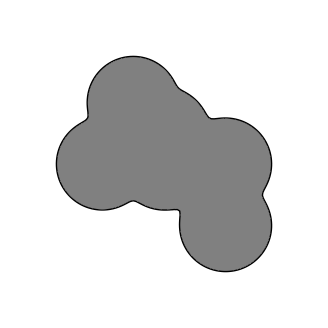

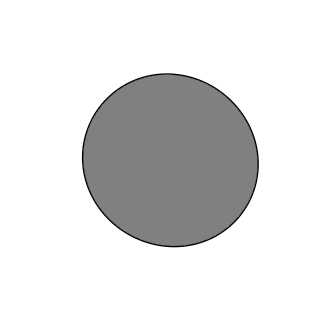

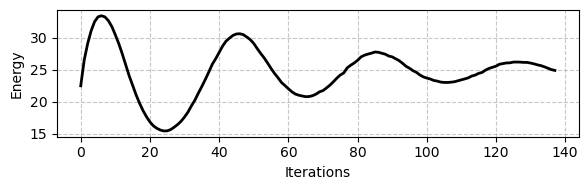

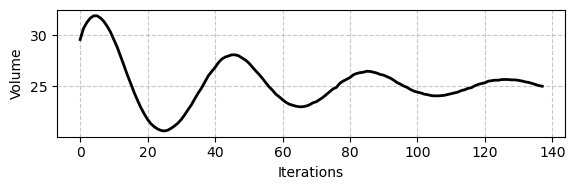

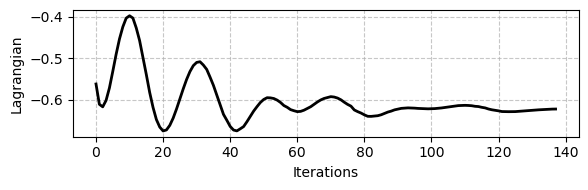

In [5]:
volume = 25.0
factor = 0.025

# Stopping condition reached!
# number of iterations = 137
# 23660 triangles
# Resolution time = 8 min

test_path = Path("../results/phiFEM/t01/")
cost_values = -(1.0/factor) * np.load(test_path / "data.npz")["cost"]
volume_values = volume * np.load(test_path / "data.npz")["ctrs"][:, 0]
lagrangian_values = np.load(test_path / "data.npz")["Lg"]
niter = cost_values.shape[0] - 1

plot_lv(test_path, 0, [[0, 10], [0, 10]], displacement=False, figsize=(4, 4))
plot_lv(test_path, niter, [[0, 10], [0, 10]], displacement=False, figsize=(4, 4))
plot2(cost_values, "Energy", (6, 2))
plot2(volume_values, "Volume", (6, 2))
plot2(lagrangian_values, "Lagrangian", (6, 2))

# Compliance minimization

In [10]:
!mpirun -np 1 python phiFEM.py 02 > ../results/phiFEM/t02/out.txt

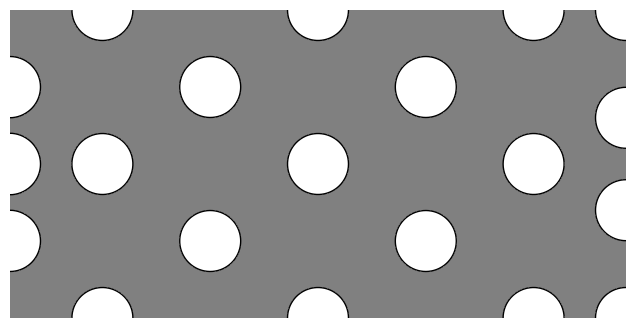

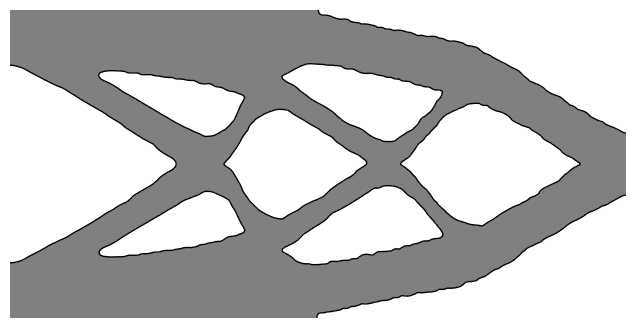

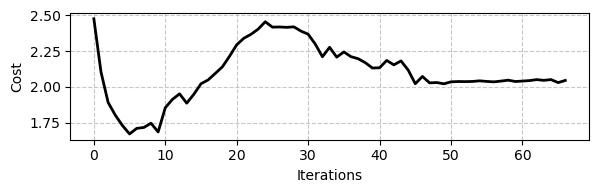

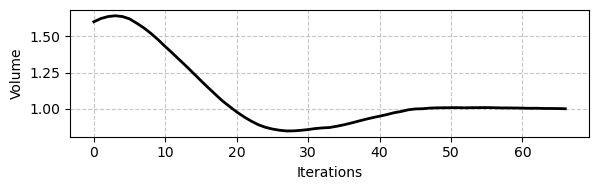

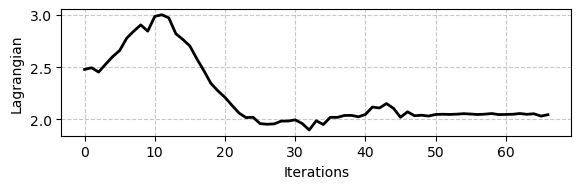

In [11]:
factor = 1.0
volume = 1.0

test_path = Path("../results/phiFEM/t02/")
cost_values = (1.0/factor) * np.load(test_path / "data.npz")["cost"]
volume_values = volume * np.load(test_path / "data.npz")["ctrs"][:, 0]
lagrangian_values = np.load(test_path / "data.npz")["Lg"]
volume_values = np.load(test_path / "data.npz")["Volume"]
niter = cost_values.shape[0] - 1

plot_lv(test_path, 0, [[0, 2], [0, 1]], displacement=False, figsize=(8, 4))
plot_lv(test_path, niter, [[0, 2], [0, 1]], displacement=False, figsize=(8, 4))
plot2(cost_values, "Cost", (6, 2))
plot2(volume_values, "Volume", (6, 2))
plot2(lagrangian_values, "Lagrangian", (6, 2))